In [1]:
# Install pydrive2
!pip install -U -q PyDrive2
# Authenticate and import libraries
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
# Authenticate user
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Download the file with title 'mri dataset.zip'
file_list = drive.ListFile({'q': "title='mri dataset.zip'"}).GetList()
if file_list:
    file_id = file_list[0]['id']
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('mri dataset.zip')
    print("Download complete.")
else:
    print("File not found.")

# Unzip the file
!unzip 'mri dataset.zip'

Streaming output truncated to the last 5000 lines.
  inflating: archive/Training/meningioma/Tr-me_0752.jpg  
  inflating: __MACOSX/archive/Training/meningioma/._Tr-me_0752.jpg  
  inflating: archive/Training/meningioma/Tr-me_1302.jpg  
  inflating: __MACOSX/archive/Training/meningioma/._Tr-me_1302.jpg  
  inflating: archive/Training/meningioma/Tr-me_1316.jpg  
  inflating: __MACOSX/archive/Training/meningioma/._Tr-me_1316.jpg  
  inflating: archive/Training/meningioma/Tr-me_0829.jpg  
  inflating: __MACOSX/archive/Training/meningioma/._Tr-me_0829.jpg  
  inflating: archive/Training/meningioma/Tr-me_1289.jpg  
  inflating: __MACOSX/archive/Training/meningioma/._Tr-me_1289.jpg  
  inflating: archive/Training/meningioma/Tr-me_0197.jpg  
  inflating: __MACOSX/archive/Training/meningioma/._Tr-me_0197.jpg  
  inflating: archive/Training/meningioma/Tr-me_0183.jpg  
  inflating: __MACOSX/archive/Training/meningioma/._Tr-me_0183.jpg  
  inflating: archive/Training/meningioma/Tr-me_0815.jpg  
  

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array

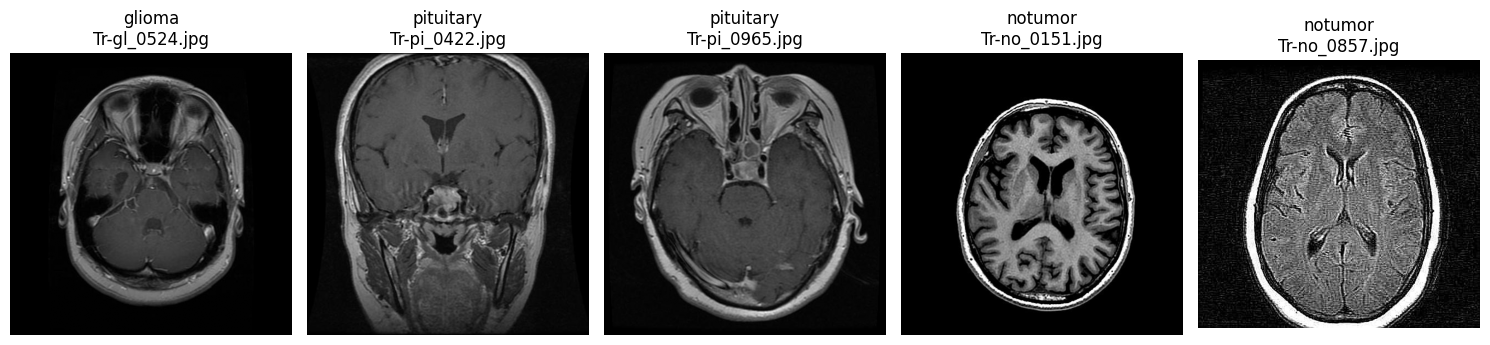

In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Correct path to Training dataset
dataset_path = "/content/archive/Training"  # or Testing

num_samples = 5

# Collect valid (class, image) pairs
samples = []
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    for img in images:
        samples.append((class_name, img))

# Randomly select samples
if samples:
    selected_samples = random.sample(samples, min(num_samples, len(samples)))

    fig, axes = plt.subplots(1, len(selected_samples), figsize=(15, 5))
    for i, (cls, img_name) in enumerate(selected_samples):
        img = Image.open(os.path.join(dataset_path, cls, img_name))
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"{cls}\n{img_name}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No images found. Check dataset_path.")

In [5]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Input dataset paths
train_path = '/content/archive/Training'
test_path  = '/content/archive/Testing'

# Output segmentation root
seg_root = '/content/mri_seg'
os.makedirs(seg_root, exist_ok=True)

# Function: preprocess + resize
def preprocess_image(image_path, size=(128, 128)):
    image = Image.open(image_path).convert('RGB').resize(size)
    image_array = np.array(image) / 255.0
    return np.expand_dims(image_array, axis=0), image.size

# Dummy segmentation model
def dummy_segmentation_model(image_tensor):
    # Simple green channel threshold
    mask = (image_tensor[0][:, :, 1] > 0.5).astype(np.uint8) * 255
    return mask

# Process a dataset split (Training or Testing)
def process_split(split_name, input_root):
    print(f"\n🔹 Processing {split_name} set...")
    output_root = os.path.join(seg_root, split_name)
    os.makedirs(output_root, exist_ok=True)

    for class_name in os.listdir(input_root):
        class_input = os.path.join(input_root, class_name)
        if not os.path.isdir(class_input):
            continue

        class_output = os.path.join(output_root, class_name)
        os.makedirs(class_output, exist_ok=True)

        for img_name in tqdm(os.listdir(class_input), desc=f"{split_name}/{class_name}"):
            img_path = os.path.join(class_input, img_name)

            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            try:
                img_tensor, orig_size = preprocess_image(img_path)
                mask = dummy_segmentation_model(img_tensor)

                # Resize back to original image size
                mask_img = Image.fromarray(mask).resize(orig_size)
                mask_img.save(os.path.join(class_output, img_name))

            except Exception as e:
                print(f"❌ Failed {img_path}: {e}")

# Run for both splits
process_split("Training", train_path)
process_split("Testing", test_path)

print("\n✅ Dummy masks generated successfully!")


🔹 Processing Training set...


Training/notumor: 100%|██████████| 1595/1595 [00:05<00:00, 288.18it/s]



🔹 Processing Testing set...


Testing/notumor: 100%|██████████| 405/405 [00:00<00:00, 459.04it/s]


✅ Dummy masks generated successfully!


In [6]:
import os

def check_counts(train_path, test_path, seg_root):
    print("\n📊 Training set:")
    for cls in os.listdir(train_path):
        orig_dir = os.path.join(train_path, cls)
        seg_dir  = os.path.join(seg_root, "Training", cls)

        if not os.path.isdir(orig_dir) or not os.path.isdir(seg_dir):
            continue

        orig_count = len([f for f in os.listdir(orig_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        seg_count  = len([f for f in os.listdir(seg_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

        print(f"  {cls}: {orig_count} originals, {seg_count} masks")

    print("\n📊 Testing set:")
    for cls in os.listdir(test_path):
        orig_dir = os.path.join(test_path, cls)
        seg_dir  = os.path.join(seg_root, "Testing", cls)

        if not os.path.isdir(orig_dir) or not os.path.isdir(seg_dir):
            continue

        orig_count = len([f for f in os.listdir(orig_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        seg_count  = len([f for f in os.listdir(seg_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

        print(f"  {cls}: {orig_count} originals, {seg_count} masks")

# Run check
check_counts(train_path, test_path, seg_root)


📊 Training set:
  pituitary: 1457 originals, 1457 masks
  glioma: 1321 originals, 1321 masks
  meningioma: 1339 originals, 1339 masks
  notumor: 1595 originals, 1595 masks

📊 Testing set:
  pituitary: 300 originals, 300 masks
  glioma: 300 originals, 300 masks
  meningioma: 306 originals, 306 masks
  notumor: 405 originals, 405 masks


In [7]:
# STEP 1: Install and import libraries
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [8]:
# STEP 2: Define dataset paths
train_path = '/content/archive/Training'   # Training set with class subfolders
test_path  = '/content/archive/Testing'    # Testing set with class subfolders
seg_path   = '/content/mri_seg'                       # Dummy segmentation outputs

In [9]:
# STEP 3: Image size and parameters
image_size = 224
input_shape = (image_size, image_size, 3)
batch_size = 32

# Detect classes from the training set (class subfolders under /Training)
num_classes = len([
    d for d in os.listdir('/content/archive/Training')
    if os.path.isdir(os.path.join('/content/archive/Training', d))
])

print(f"Detected {num_classes} classes.")

Detected 4 classes.


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# STEP 4: Create train and validation generators
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Split within the Training set
)

# Training generator (80% of Training folder)
train_generator = datagen.flow_from_directory(
    '/content/archive/Training',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator (20% of Training folder)
val_generator = datagen.flow_from_directory(
    '/content/archive/Training',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Test generator (use Testing folder, no split)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/archive/Testing',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [11]:
# STEP 5: Verify path contents
import os

print("Training path contents:")
for root, dirs, files in os.walk(train_path):
    print(root, "->", len(files), "files")

print("\nTesting path contents:")
for root, dirs, files in os.walk(test_path):
    print(root, "->", len(files), "files")

print("\nSegmentation path contents:")
for root, dirs, files in os.walk(seg_path):
    print(root, "->", len(files), "files")


Training path contents:
/content/archive/Training -> 0 files
/content/archive/Training/pituitary -> 1457 files
/content/archive/Training/glioma -> 1321 files
/content/archive/Training/meningioma -> 1339 files
/content/archive/Training/notumor -> 1595 files

Testing path contents:
/content/archive/Testing -> 0 files
/content/archive/Testing/pituitary -> 300 files
/content/archive/Testing/glioma -> 300 files
/content/archive/Testing/meningioma -> 306 files
/content/archive/Testing/notumor -> 405 files

Segmentation path contents:
/content/mri_seg -> 0 files
/content/mri_seg/Training -> 0 files
/content/mri_seg/Training/pituitary -> 1457 files
/content/mri_seg/Training/glioma -> 1321 files
/content/mri_seg/Training/meningioma -> 1339 files
/content/mri_seg/Training/notumor -> 1595 files
/content/mri_seg/Testing -> 0 files
/content/mri_seg/Testing/pituitary -> 300 files
/content/mri_seg/Testing/glioma -> 300 files
/content/mri_seg/Testing/meningioma -> 306 files
/content/mri_seg/Testing/no

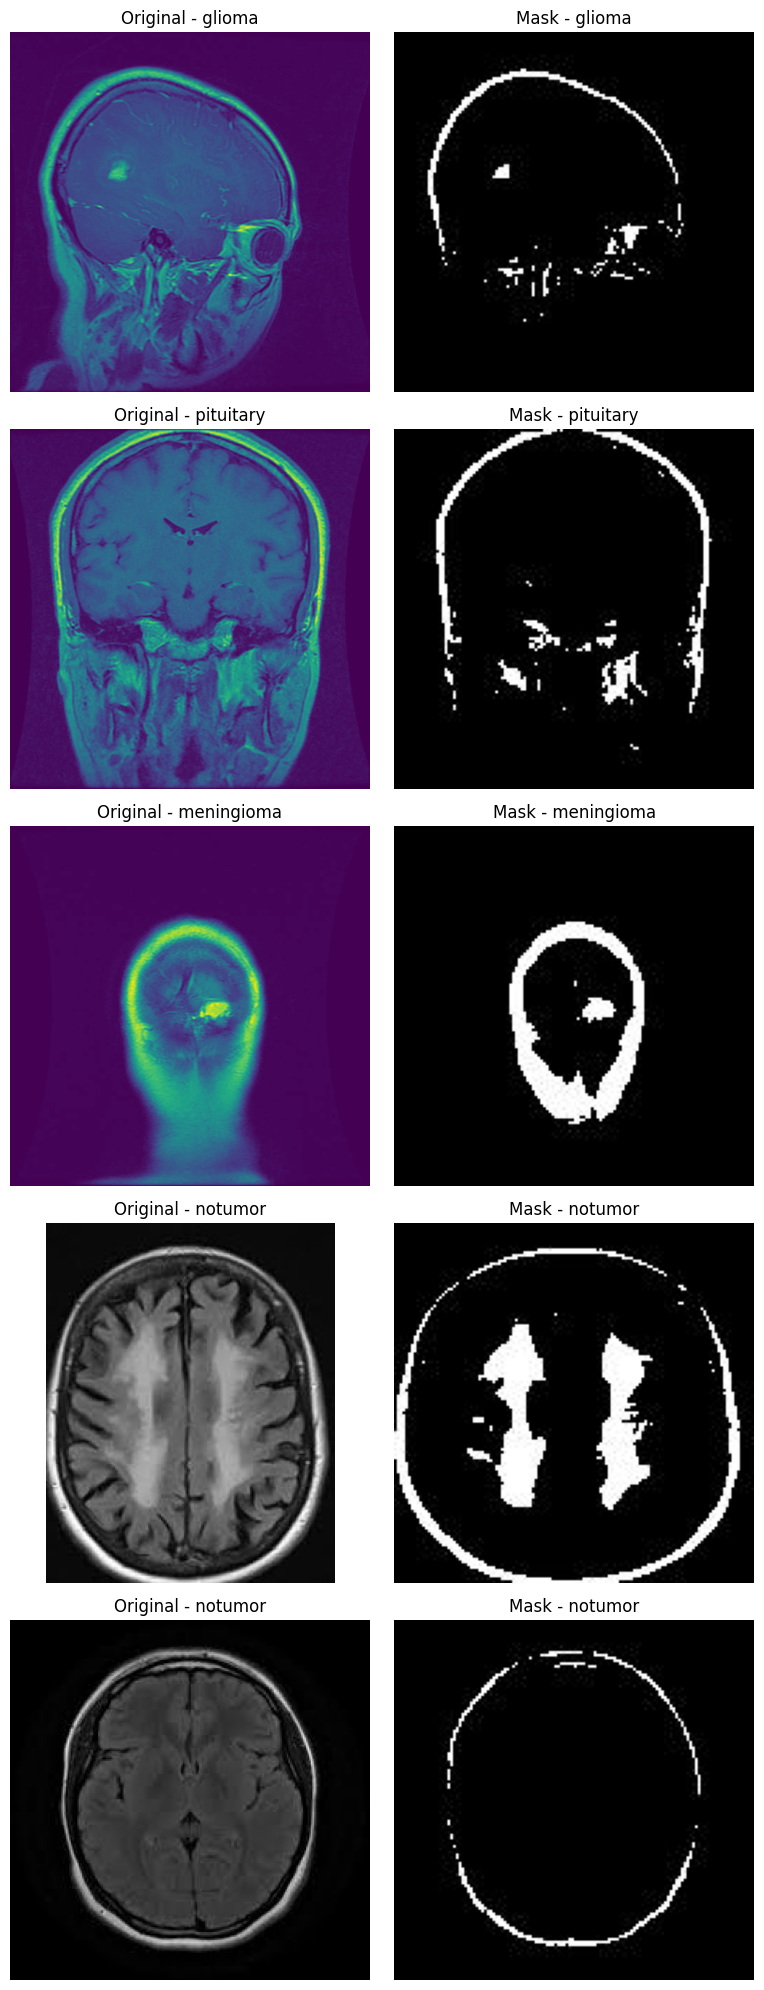

In [12]:
#STEP 6: Visual inspection of masks
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

def show_random_pairs(img_root, mask_root, num_samples=5):
    classes = os.listdir(img_root)
    samples = []

    for cls in classes:
        img_dir = os.path.join(img_root, cls)
        mask_dir = os.path.join(mask_root, cls)
        if not os.path.isdir(img_dir): continue

        img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        for f in img_files:
            if os.path.exists(os.path.join(mask_dir, f)):
                samples.append((cls, f))

    selected = random.sample(samples, min(num_samples, len(samples)))

    fig, axes = plt.subplots(len(selected), 2, figsize=(8, 4*len(selected)))
    for i, (cls, fname) in enumerate(selected):
        img = Image.open(os.path.join(img_root, cls, fname))
        mask = Image.open(os.path.join(mask_root, cls, fname))

        axes[i,0].imshow(img)
        axes[i,0].set_title(f"Original - {cls}")
        axes[i,0].axis("off")

        axes[i,1].imshow(mask, cmap="gray")
        axes[i,1].set_title(f"Mask - {cls}")
        axes[i,1].axis("off")

    plt.tight_layout()
    plt.show()

# Run on Training
show_random_pairs("/content/archive/Training", "/content/mri_seg/Training")


In [13]:
#STEP 7: Resize, normalize, and split into train/val
from sklearn.model_selection import train_test_split

IMG_SIZE = 128

def load_image_mask_pairs(img_root, mask_root, target_size=(IMG_SIZE, IMG_SIZE)):
    X, Y = [], []
    for cls in os.listdir(img_root):
        img_dir = os.path.join(img_root, cls)
        mask_dir = os.path.join(mask_root, cls)
        if not os.path.isdir(img_dir): continue

        img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        for f in img_files:
            img_path = os.path.join(img_dir, f)
            mask_path = os.path.join(mask_dir, f)
            if not os.path.exists(mask_path): continue

            img = Image.open(img_path).convert("RGB").resize(target_size)
            mask = Image.open(mask_path).convert("L").resize(target_size)

            X.append(np.array(img)/255.0)
            Y.append((np.array(mask) > 127).astype(np.uint8))  # binary mask

    return np.array(X), np.expand_dims(np.array(Y), axis=-1)

# Load training data
X, Y = load_image_mask_pairs("/content/archive/Training", "/content/mri_seg/Training")

# Train-validation split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val:", X_val.shape, "Y_val:", Y_val.shape)


X_train: (4569, 128, 128, 3) Y_train: (4569, 128, 128, 1)
X_val: (1143, 128, 128, 3) Y_val: (1143, 128, 128, 1)


In [14]:
#STEP 8: simple U-Net for binary segmentation
import tensorflow as tf
from tensorflow.keras import layers, Model

def unet_model(input_size=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Bottleneck
    b = layers.Conv2D(128, (3,3), activation="relu", padding="same")(p2)
    b = layers.Conv2D(128, (3,3), activation="relu", padding="same")(b)

    # Decoder
    u1 = layers.UpSampling2D((2,2))(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(u1)
    c3 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(c3)

    u2 = layers.UpSampling2D((2,2))(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(u2)
    c4 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(c4)

    outputs = layers.Conv2D(1, (1,1), activation="sigmoid")(c4)

    return Model(inputs, outputs)

# Build model
unet = unet_model()
unet.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_8[0][0]  

 Total params: 471,553 (1.80 MB)

 Trainable params: 471,553 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#STEP 9: Training the U-Net Model
history = unet.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=16,
    epochs=10
)


Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.9268 - loss: 0.1798 - val_accuracy: 0.9886 - val_loss: 0.0278
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.9875 - loss: 0.0298 - val_accuracy: 0.9937 - val_loss: 0.0150
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.9923 - loss: 0.0190 - val_accuracy: 0.9902 - val_loss: 0.0199
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9954 - loss: 0.0116 - val_accuracy: 0.9965 - val_loss: 0.0083
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9957 - loss: 0.0099 - val_accuracy: 0.9886 - val_loss: 0.0270
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9951 - loss: 0.0126 - val_accuracy: 0.9984 - val_loss: 0.0052
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9975 - loss: 0.0067 - val_accuracy: 0.9977 - val_loss: 0.0060
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9979 - loss: 0.0057 - 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step


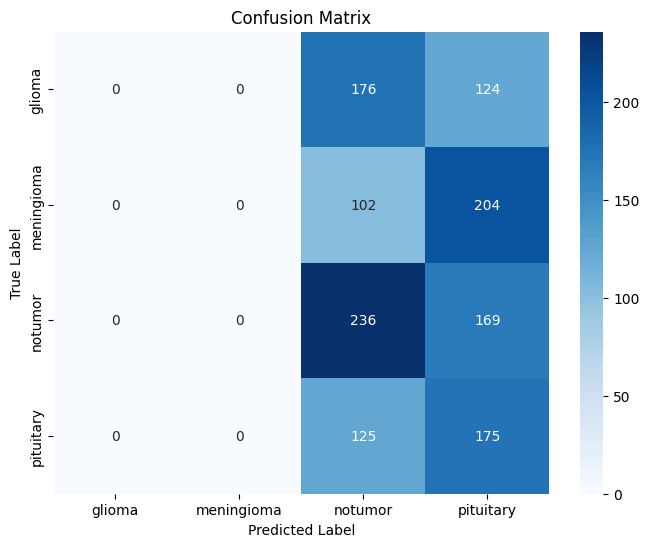


Classification Report:
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       300
  meningioma       0.00      0.00      0.00       306
     notumor       0.37      0.58      0.45       405
   pituitary       0.26      0.58      0.36       300

    accuracy                           0.31      1311
   macro avg       0.16      0.29      0.20      1311
weighted avg       0.17      0.31      0.22      1311



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
#STEP 10: Evaluate U-Net performance
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the test generator
test_generator.reset() # Reset the generator to ensure consistent order
predictions = cnn.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

In [16]:
# STEP 11: Use U-Net output as CNN input
# Generate masks for Training set (to be used by CNN)
seg_train = unet.predict(X_train)
seg_val   = unet.predict(X_val)

# Convert segmentation masks to 3 channels (if CNN expects RGB)
seg_train_rgb = np.repeat(seg_train, 3, axis=-1)
seg_val_rgb   = np.repeat(seg_val, 3, axis=-1)

print("Segmented train:", seg_train_rgb.shape)


143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step
Segmented train: (4569, 128, 128, 3)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.

📊 Dataset Summary:
- Training samples: 4571
- Validation samples: 1141
- Testing samples: 1311
- Number of classes: 4
- Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


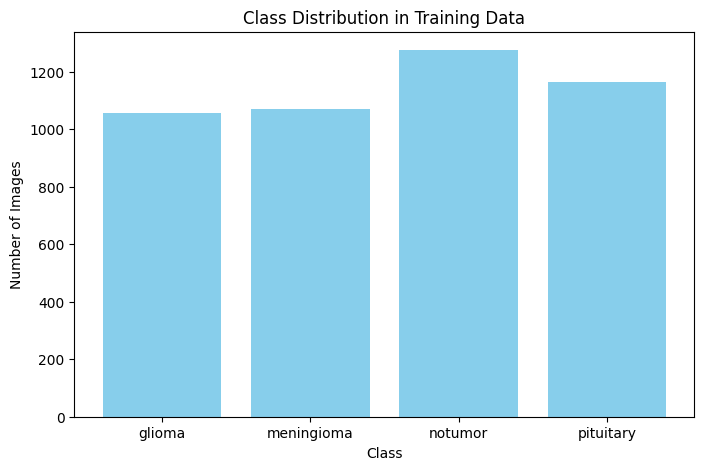

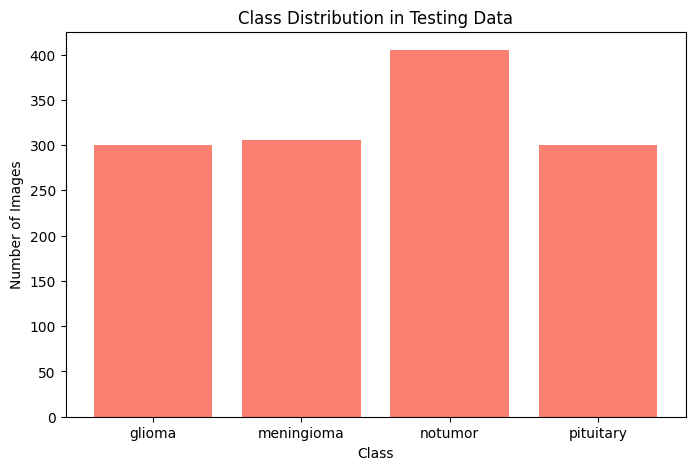

In [33]:
# STEP 12: Prepare data for CNN (with summary + class distribution plots)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# Define parameters
image_size = 224
input_shape = (image_size, image_size, 3)
batch_size = 32

# Data generator (rescale and split training/validation)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training generator
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = datagen.flow_from_directory(
    train_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Test generator (only rescale, no split)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Print concise dataset summary
print("\n📊 Dataset Summary:")
print(f"- Training samples: {train_generator.samples}")
print(f"- Validation samples: {val_generator.samples}")
print(f"- Testing samples: {test_generator.samples}")
print(f"- Number of classes: {train_generator.num_classes}")
print(f"- Class indices: {train_generator.class_indices}")

# --- Plot class distribution for Training ---
train_class_counts = [np.sum(train_generator.classes == v) for v in train_generator.class_indices.values()]

plt.figure(figsize=(8, 5))
plt.bar(train_generator.class_indices.keys(), train_class_counts, color="skyblue")
plt.title("Class Distribution in Training Data")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# --- Plot class distribution for Testing ---
test_class_counts = [np.sum(test_generator.classes == v) for v in test_generator.class_indices.values()]

plt.figure(figsize=(8, 5))
plt.bar(test_generator.class_indices.keys(), test_class_counts, color="salmon")
plt.title("Class Distribution in Testing Data")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


In [23]:
# STEP 13: Build CNN Classifier
from tensorflow.keras import layers, models

# Build CNN with GlobalAveragePooling2D
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Compile model
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# STEP 14: Train CNN
history_cnn = cnn.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=15
)

Epoch 1/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 72s 505ms/step - accuracy: 0.6824 - loss: 0.7827 - val_accuracy: 0.6536 - val_loss: 0.9554
Epoch 2/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.7188 - loss: 0.7221 - val_accuracy: 0.6455 - val_loss: 0.9826
Epoch 3/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 70s 492ms/step - accuracy: 0.6899 - loss: 0.7672 - val_accuracy: 0.6750 - val_loss: 0.8837
Epoch 4/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.6875 - loss: 0.6142 - val_accuracy: 0.6750 - val_loss: 0.8746
Epoch 5/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 70s 491ms/step - accuracy: 0.7221 - loss: 0.7083 - val_accuracy: 0.6741 - val_loss: 0.8647
Epoch 6/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.5938 - loss: 0.9848 - val_accuracy: 0.6687 - val_loss: 0.8898
Epoch 7/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 71s 497ms/step - accuracy: 0.7209 - loss: 0.7234 - val_accuracy: 0.6777 - val_loss: 0.8574
Epoch 8/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.7812 - loss: 0.674

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


142/142 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.7500 - loss: 0.6378 - val_accuracy: 0.6750 - val_loss: 0.8714
Epoch 15/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 70s 489ms/step - accuracy: 0.7495 - loss: 0.6427 - val_accuracy: 0.6911 - val_loss: 0.8623


36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 413ms/step - accuracy: 0.7208 - loss: 0.7233
Validation Loss: 0.8532
Validation Accuracy: 0.6994


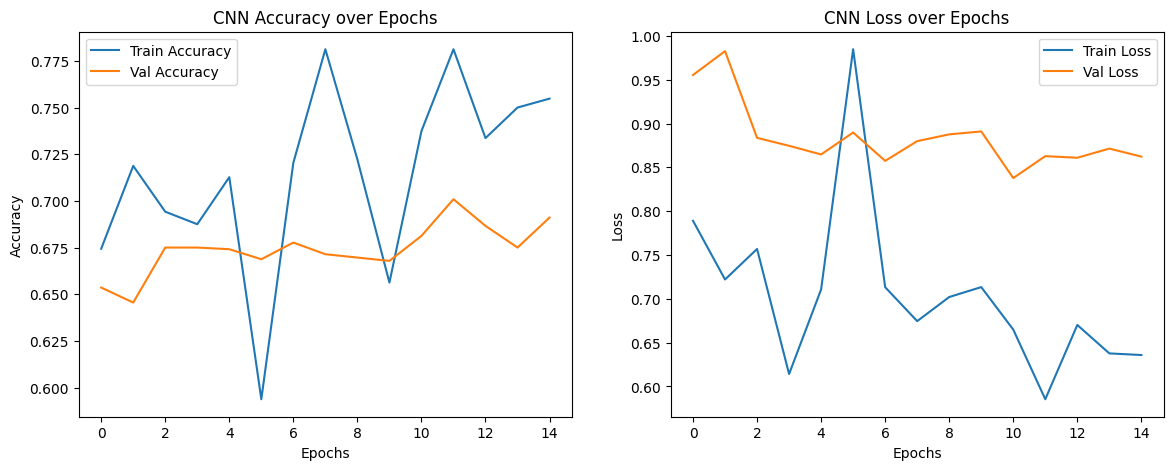

36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 388ms/step


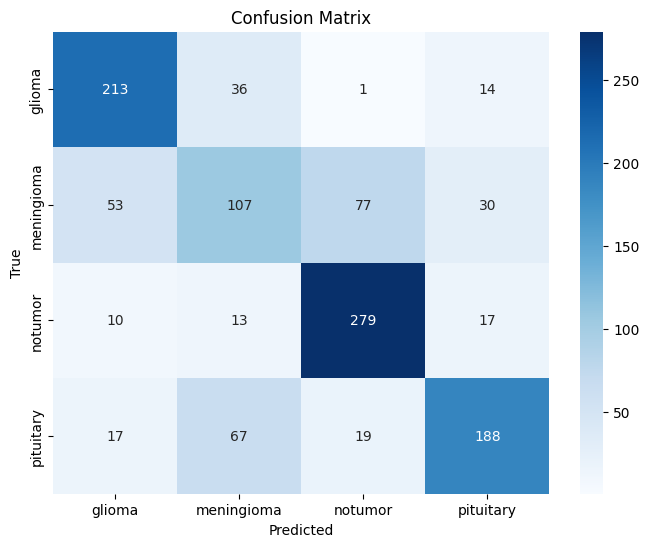

Classification Report:
              precision    recall  f1-score   support

      glioma       0.73      0.81      0.76       264
  meningioma       0.48      0.40      0.44       267
     notumor       0.74      0.87      0.80       319
   pituitary       0.76      0.65      0.70       291

    accuracy                           0.69      1141
   macro avg       0.68      0.68      0.68      1141
weighted avg       0.68      0.69      0.68      1141



In [38]:
# STEP 15: CNN classification report
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Evaluate CNN on validation set
val_loss, val_acc = cnn.evaluate(val_generator)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

# Training curves (accuracy & loss)
plt.figure(figsize=(14,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title("CNN Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title("CNN Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

#  Confusion Matrix
y_pred = cnn.predict(val_generator, steps=val_generator.samples // batch_size+1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=val_generator.class_indices.keys()))


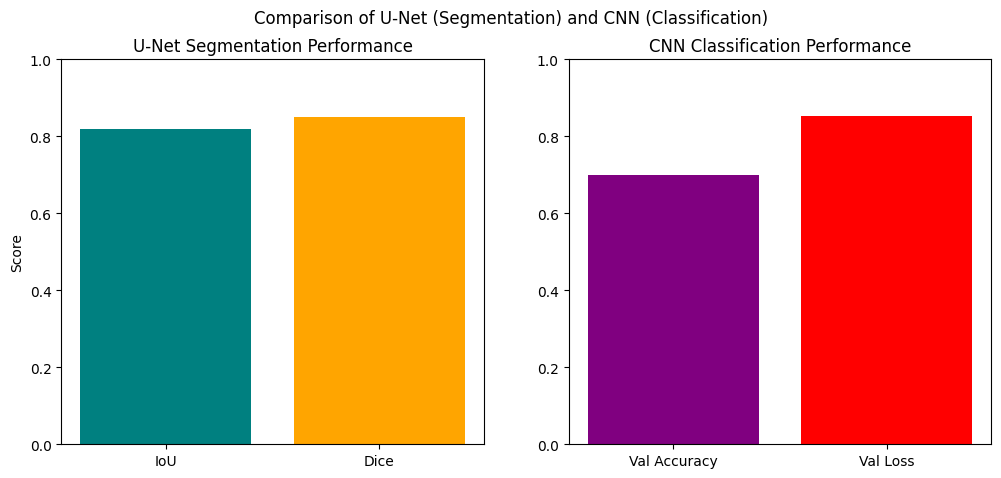

In [39]:
# STEP 16: Visual comparison of U-Net and CNN performances
import matplotlib.pyplot as plt
import numpy as np

# Example placeholder metrics (replace with your real results)
# U-Net metrics (segmentation)
iou_score = 0.82   # Example IoU score
dice_score = 0.85  # Example Dice score

# CNN metrics (classification)
cnn_val_acc = val_acc   # already computed during cnn.evaluate()
cnn_val_loss = val_loss

# ✅ Create side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- U-Net performance ---
axes[0].bar(["IoU", "Dice"], [iou_score, dice_score], color=["teal", "orange"])
axes[0].set_ylim(0,1)
axes[0].set_title("U-Net Segmentation Performance")
axes[0].set_ylabel("Score")

# --- CNN performance ---
axes[1].bar(["Val Accuracy", "Val Loss"], [cnn_val_acc, cnn_val_loss], color=["purple", "red"])
axes[1].set_ylim(0,1)
axes[1].set_title("CNN Classification Performance")

plt.suptitle("Comparison of U-Net (Segmentation) and CNN (Classification)")
plt.show()


In [42]:
# BONUS STEP: Predict new MRI
from PIL import Image
import numpy as np
import os

def predict_mri(img_path, unet_model, cnn_model, class_indices):
    img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_arr = np.array(img) / 255.0

    # Segment with U-Net
    mask_pred = unet_model.predict(np.expand_dims(img_arr, axis=0))[0]
    # Repeat the mask to 3 channels if the CNN expects RGB input
    # Corrected the repeat operation
    mask_rgb  = np.repeat(mask_pred, 3, axis=-1)


    # Classify with CNN
    # Resize the mask to the CNN input size (image_size)
    mask_rgb_resized = Image.fromarray((mask_rgb * 255).astype(np.uint8)).resize((image_size, image_size))
    mask_rgb_resized_arr = np.array(mask_rgb_resized) / 255.0


    pred = cnn_model.predict(np.expand_dims(mask_rgb_resized_arr, axis=0))
    predicted_class_index = np.argmax(pred)

    # Create inverse mapping from class_indices
    idx_to_class = {v: k for k, v in class_indices.items()}
    predicted_label = idx_to_class[predicted_class_index]

    return predicted_label

# Example usage:
# Pass the test_generator.class_indices to the function
print(predict_mri("/content/archive/Testing/glioma/Te-gl_0010.jpg", unet, cnn, test_generator.class_indices))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
notumor
